<a href="https://colab.research.google.com/github/mitsu-hm/Google-Collab/blob/main/AIML_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
dataset={
    "Item Name":["A","B","C","D","E"],
     "Item Value":[2,4,6,8,10]
}

In [ ]:
df=pd.DataFrame(dataset)
print(df)

  Item Name  Item Value
0         A           2
1         B           4
2         C           6
3         D           8
4         E          10


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Z-Score"] = scaler.fit_transform(df[["Item Value"]])

print(df)

  Item Name  Item Value   Z-Score
0         A           2 -1.414214
1         B           4 -0.707107
2         C           6  0.000000
3         D           8  0.707107
4         E          10  1.414214


In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/AIML/train.csv')

In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.shape

(891, 12)

In [ ]:
df.select_dtypes(include=['object']).columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [ ]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
df['Ticket'].value_counts()

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


In [ ]:
df['Sex']= df['Sex'].map({'male' : 0,'female' : 1})

In [ ]:
df['Sex']

,Sex
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,1
889,0


In [ ]:
df['Embarked']=df['Embarked'].map({'S': 0,'C': 1,'Q': 2})

In [ ]:
df['Embarked']

,Embarked
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0
...,...
886,0.0
887,0.0
888,0.0
889,1.0


In [ ]:
df.drop(columns=['Ticket'], inplace=True, errors='ignore')

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

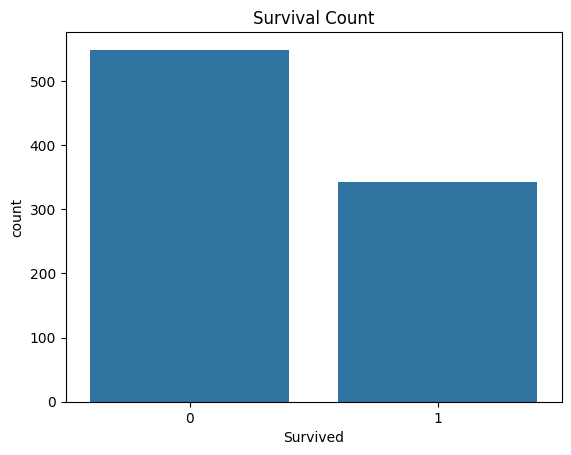

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

In [ ]:
df[df['Survived'] ==1]['Sex'].value_counts()

,count
Sex,
1,233
0,109


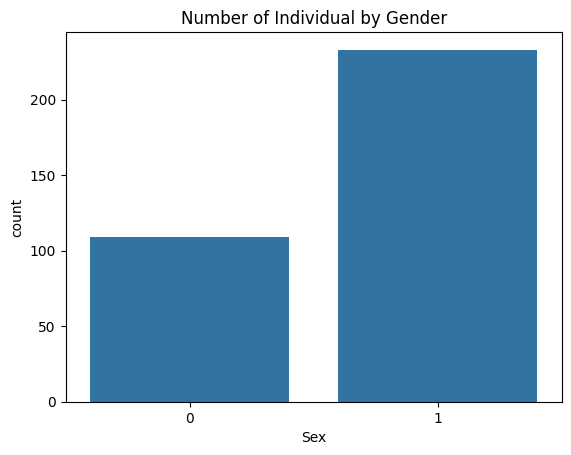

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(
x='Sex',
data=df[df['Survived']==1]
)
plt.title("Number of Individual by Gender")
plt.show()

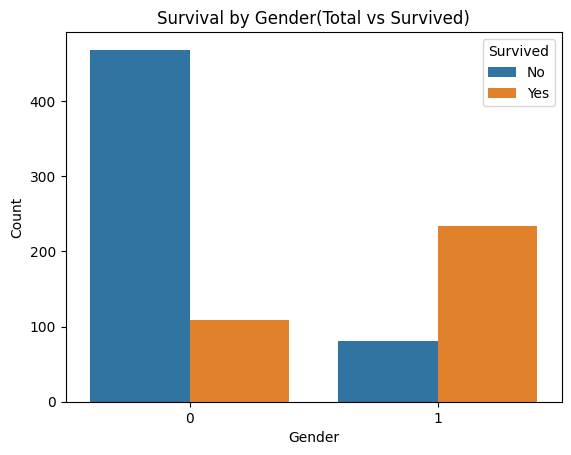

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(
x='Sex',
hue='Survived',
data=df
)
plt.title("Survival by Gender(Total vs Survived)")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=['Sex','Embarked'],
    drop_first=True
)

In [ ]:
feature_X = ['pclass','age','fare','Sex_1']
target_y = ['Survived']

In [ ]:
feature_X = ['Pclass', 'Age','Fare','Sex']
train_X=df[feature_X]
train_y=df[target_y]

In [ ]:
train_X

,Pclass,Age,Fare,Sex
0,3,22.0,7.2500,0
1,1,38.0,71.2833,1
2,3,26.0,7.9250,1
3,1,35.0,53.1000,1
4,3,35.0,8.0500,0
...,...,...,...,...
886,2,27.0,13.0000,0
887,1,19.0,30.0000,1
888,3,28.0,23.4500,1
889,1,26.0,30.0000,0


In [ ]:
from sklearn.linear_model import LogisticRegression
df['Age'].fillna(df['Age'].median(),inplace=True)
train_X=df[feature_X]
train_y=df[target_y]
model = LogisticRegression(max_iter=1000)
model.fit(train_X, train_y)

/tmp/ipython-input-1379761431.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score
train_pred_y= model.predict(train_X)
train_accuracy=accuracy_score(train_y,train_pred_y)
print("Training Accuracy:",train_accuracy)

Training Accuracy: 0.7991021324354658


In [ ]:
import numpy as np
import pandas as pd

print("Enter Passenger Details:")
pclass = int(input("Passenger Class (1/2/3)："))
# Sex is not part of the trained features, so removing it from Input
age = float(input("Age:"))
#fare = float(input("Fare:“))
# Arrange input in same order as training data: 'pclass', 'age'
# Gender=int(input("Gender(0/1):“)) # Removed as it's not part of the trained features
input_data = np.array([[pclass, age]]) # Only include Pclass and Age

# Convert input_data to DataFrame with feature names to match training data
input_df = pd.DataFrame(input_data, columns=feature_X)

prediction = model.predict(input_df)

if prediction[0] == 1:
    print("Prediction: Passenger Survived")
else:
    print("Prediction: Passenger Did NOT Survive")

Enter Passenger Details:
Passenger Class (1/2/3)：1
Age:25
Prediction: Passenger Survived


In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,NaN,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C85,1.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,NaN,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,C123,0.0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,13.0000,NaN,0.0
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,30.0000,B42,0.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,23.4500,NaN,0.0
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,30.0000,C148,1.0


In [ ]:
X=df.drop('Survived', axis=1)
y=df['Survived']
display(X.head(10))
display(y.head(10))

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,NaN,0.0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C85,1.0
2,3,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,NaN,0.0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,C123,0.0
4,5,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,NaN,0.0
5,6,3,"Moran, Mr. James",0,28.0,0,0,8.4583,NaN,2.0
6,7,1,"McCarthy, Mr. Timothy J",0,54.0,0,0,51.8625,E46,0.0
7,8,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,21.0750,NaN,0.0
8,9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,11.1333,NaN,0.0
9,10,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,30.0708,NaN,1.0


,Survived
0,0
1,1
2,1
3,1
4,0
5,0
6,0
7,0
8,1
9,1


In [ ]:
df_encoded.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Fare', 'Cabin', 'Sex_1', 'Embarked_1.0', 'Embarked_2.0'],
      dtype='object')

In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Cabin,object


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train_X,train_y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape,X_test.shape

((712, 4), (179, 4))

In [ ]:
X_train[feature_X].isnull().sum()

,0
Pclass,0
Age,0
Fare,0
Sex,0


In [ ]:
inital_feature_X =['age','pclass','sex','sibsp','parch','fare']
target_y_col ='Survived'

In [ ]:
X_train = X_train[feature_X]
X_test = X_test[feature_X]
X_train.head()
X_test.head()

,Pclass,Age,Fare,Sex
709,3,28.0,15.2458,0
439,2,31.0,10.5000,0
840,3,20.0,7.9250,0
720,2,6.0,33.0000,1
39,3,14.0,11.2417,1


In [ ]:
model =LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score
train_pred_y= model.predict(train_X)
train_accuracy=accuracy_score(train_y,train_pred_y)
print("Training Accuracy:",train_accuracy)


Training Accuracy: 0.7934904601571269


In [ ]:
test_pred_y = model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_pred_y)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8044692737430168
